# Initial training using chronological split

### (a) Load model-ready dataset and do train-test split

--- Random Forest ---
RF MAE: 6.3356 cents
RF R2:  0.4782

--- Linear Regression ---
Linear Regression MAE: 3.3091 cents
Linear Regression R2:  0.8047



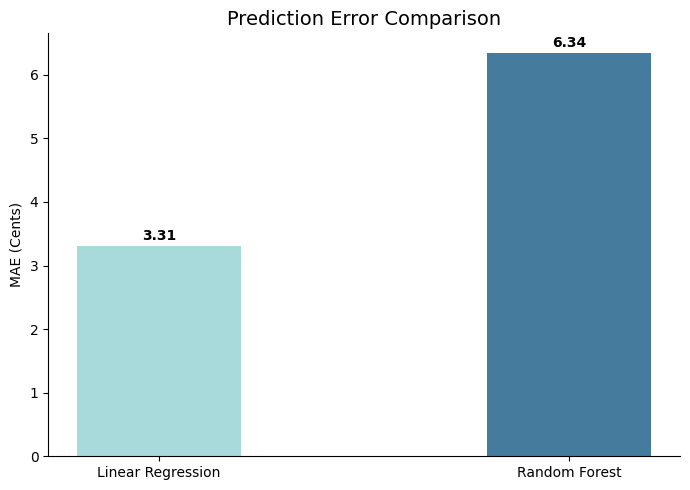

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler # <-- Import Scaler
from sklearn.metrics import mean_absolute_error, r2_score

COMPLETE_DATASET = 'datasets/YEAR_COMPLETE_DATASET.csv'
MODEL_READY_DATASET = 'datasets/MODEL_READY_DATASET5.csv'

# Load model-ready dataset
try:
    df = pd.read_csv(MODEL_READY_DATASET)
except NameError:
    print(f"Error: MODEL_READY_DATASET does not exist yet")
    print("Please run the preprocessing notebook")
    raise SystemExit

# 2. Apply the SAME Chronological Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# 3. Separate features and target
target_col = 'target_fuel_price_tomorrow'
X_train_chrono = train_df.drop(columns=[target_col])
y_train_chrono = train_df[target_col]
X_test_chrono = test_df.drop(columns=[target_col])
y_test_chrono = test_df[target_col]

# === SAFE CHRONOLOGICAL SCALING SECTION ===
# Initialize the standardizer (Z-score normalization)
scaler = StandardScaler()

# CRITICAL: Fit only on the past training data, then transform it
X_train_scaled = scaler.fit_transform(X_train_chrono)

# CRITICAL: Use the training parameters to transform the unseen future test vault
X_test_scaled = scaler.transform(X_test_chrono)
# ==========================================

# 4. Instantiate and Train the Baseline Linear Regression (Using SCALED data)
baseline_lr = LinearRegression()
baseline_lr.fit(X_train_scaled, y_train_chrono)

# 5. Generate Predictions on the future test vault
baseline_lr_preds = baseline_lr.predict(X_test_scaled)

# 6. Calculate your honest scaled linear baseline metrics
baseline_lr_mae = mean_absolute_error(y_test_chrono, baseline_lr_preds)
baseline_lr_r2 = r2_score(y_test_chrono, baseline_lr_preds)


# 7. Instantiate and Train Random Forest (Using UNSCALED data)
baseline_rf = RandomForestRegressor(
    n_estimators=100, 
    # max_depth=None,
    # min_samples_split=2,
    # min_samples_leaf=1,
    # max_features=1.0,
    # bootstrap=True,
    random_state=42, 
    n_jobs=-1
)
# We feed the raw, unscaled features here because trees are scale-invariant
baseline_rf.fit(X_train_chrono, y_train_chrono)
baseline_rf_preds = baseline_rf.predict(X_test_chrono)

baseline_rf_mae = mean_absolute_error(y_test_chrono, baseline_rf_preds)
baseline_rf_r2 = r2_score(y_test_chrono, baseline_rf_preds)

print("--- Random Forest ---")
print(f"RF MAE: {baseline_rf_mae:.4f} cents")
print(f"RF R2:  {baseline_rf_r2:.4f}\n")

print("--- Linear Regression ---")
print(f"Linear Regression MAE: {baseline_lr_mae:.4f} cents")
print(f"Linear Regression R2:  {baseline_lr_r2:.4f}\n")

plt.figure(figsize=(7, 5))
results = {'Linear Regression': baseline_lr_mae, 'Random Forest': baseline_rf_mae}
colors = ['#A8DADC', '#457B9D']

bars = plt.bar(results.keys(), results.values(), color=colors, width=0.4)

# Scientific styling
plt.title('Prediction Error Comparison', fontsize=14)
plt.ylabel('MAE (Cents)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 Feature Importance & Impact Analysis: Random Forest vs. Linear Regression

To understand *how* our models are predicting tomorrow's fuel prices, we can visualize their internal decision-making parameters side-by-side:

1. **Linear Regression (Standardized Coefficients):** These values represent both **magnitude and direction**. A positive weight means that as the feature increases, tomorrow's fuel price is driven *up* (e.g., higher wholesale TGP). A negative weight means that as the feature increases, tomorrow's price goes *down* (e.g., a stronger AUD/USD exchange rate).
2. **Random Forest (Gini Feature Importance):** These values represent **pure relative importance (0.0 to 1.0)** based on Mean Decrease in Impurity (MDI). It measures how often a specific feature was used to split a tree node and how cleanly it isolated the target variable. Because it is an absolute metric, it does not show direction, only sheer predictive power.

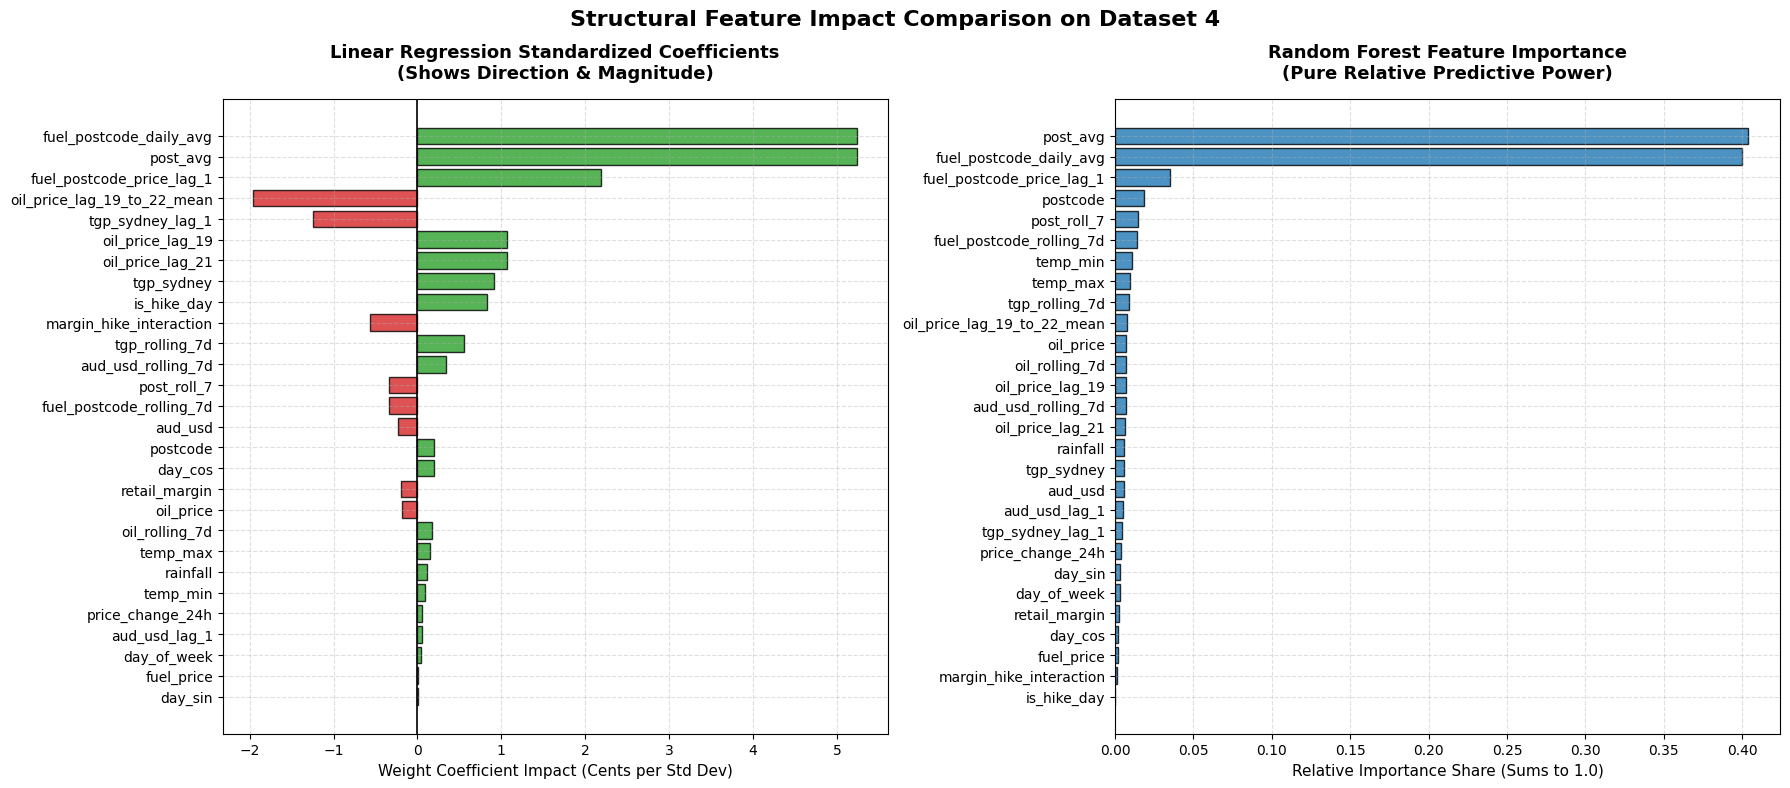

========================================= LINEAR REGRESSION WEIGHTS =========================================
                    Feature  Coefficient
    fuel_postcode_daily_avg     5.241173
                   post_avg     5.241173
  fuel_postcode_price_lag_1     2.188853
oil_price_lag_19_to_22_mean    -1.961925
           tgp_sydney_lag_1    -1.240367
           oil_price_lag_19     1.072016
           oil_price_lag_21     1.068027
                 tgp_sydney     0.906502
                is_hike_day     0.824241
    margin_hike_interaction    -0.571104
             tgp_rolling_7d     0.559843
         aud_usd_rolling_7d     0.339961
                post_roll_7    -0.333663
   fuel_postcode_rolling_7d    -0.333663
                    aud_usd    -0.227381
                   postcode     0.201315
                    day_cos     0.194378
              retail_margin    -0.192067
                  oil_price    -0.180931
             oil_rolling_7d     0.174197
                   temp_max  

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Extract Linear Regression Coefficients
lr_features = X_train_chrono.columns
lr_coefs = baseline_lr.coef_

# Create a DataFrame and sort by absolute magnitude for clean visualization
lr_importance = pd.DataFrame({
    'Feature': lr_features,
    'Coefficient': lr_coefs,
    'Absolute': np.abs(lr_coefs)
}).sort_values(by='Absolute', ascending=True) # Ascending for horizontal bar plot entry

# 2. Extract Random Forest Feature Importances
rf_importances = baseline_rf.feature_importances_

rf_importance = pd.DataFrame({
    'Feature': lr_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=True)

# 3. Construct Side-by-Side Horizontal Bar Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel 1: Linear Regression Coefficients ---
# We map colors: Red for negative price impact, Green for positive price impact
colors = ['#d62728' if c < 0 else '#2ca02c' for c in lr_importance['Coefficient']]

axes[0].barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.2)
axes[0].set_title('Linear Regression Standardized Coefficients\n(Shows Direction & Magnitude)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Weight Coefficient Impact (Cents per Std Dev)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Panel 2: Random Forest Feature Importance ---
axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='#1f77b4', edgecolor='black', alpha=0.8)
axes[1].set_title('Random Forest Feature Importance\n(Pure Relative Predictive Power)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Relative Importance Share (Sums to 1.0)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

# 4. Global Plot Adjustments
plt.suptitle('Structural Feature Impact Comparison on Dataset 4', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 5. Print out the raw tabular values underneath for precise inspection
print("="*41 + " LINEAR REGRESSION WEIGHTS " + "="*41)
print(lr_importance[['Feature', 'Coefficient']].sort_values(by='Coefficient', key=abs, ascending=False).to_string(index=False))
print("\n" + "="*43 + " RANDOM FOREST IMPURITY " + "="*43)
print(rf_importance.sort_values(by='Importance', ascending=False).to_string(index=False))

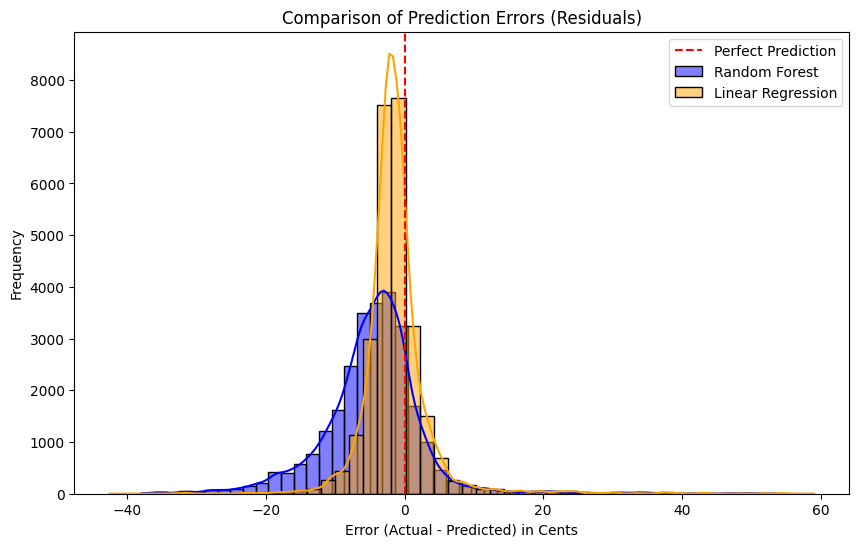

In [3]:
import seaborn as sns
# Calculate residuals
rf_residuals = y_test_chrono - baseline_rf_preds
lr_residuals = y_test_chrono - baseline_lr_preds

plt.figure(figsize=(10, 6))

# Plot Random Forest Residuals
sns.histplot(rf_residuals, kde=True, bins=50, color='blue', label='Random Forest', alpha=0.5)

# Plot Linear Regression Residuals
sns.histplot(lr_residuals, kde=True, bins=50, color='orange', label='Linear Regression', alpha=0.5)

# Formatting
plt.title('Comparison of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Perfect Prediction')
plt.legend() # This adds the labels to the plot
plt.show()

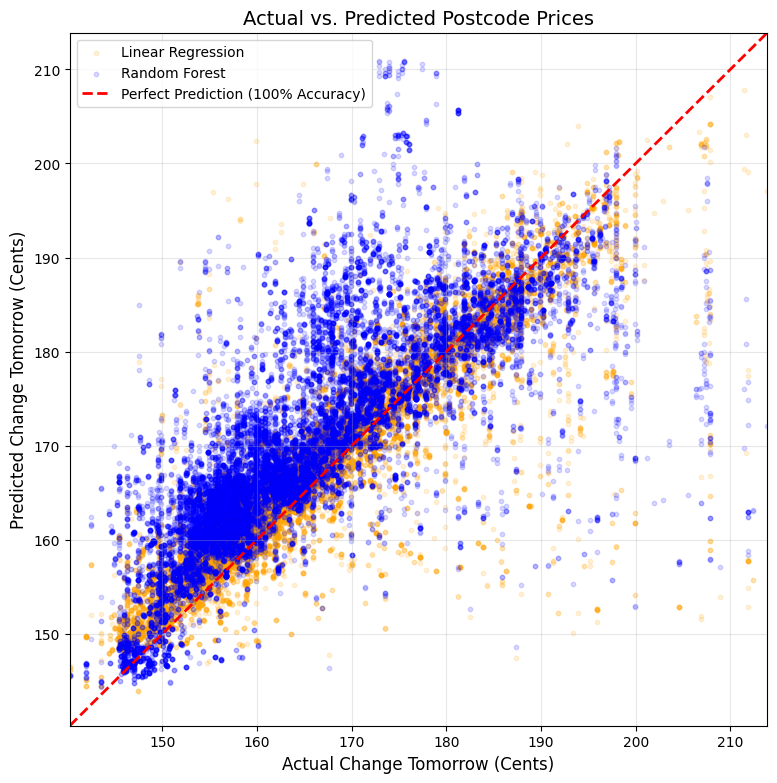

In [4]:
plt.figure(figsize=(9, 9))

# Plot Linear Regression
plt.scatter(y_test_chrono, baseline_lr_preds, alpha=0.15, color='orange', label='Linear Regression', s=10)

# Plot Random Forest
plt.scatter(y_test_chrono, baseline_rf_preds, alpha=0.15, color='blue', label='Random Forest', s=10)

# Perfect Prediction Line
line_range = [y_test_chrono.min(), y_test_chrono.max()]
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Prediction (100% Accuracy)')

# Refined Labels for the Delta approach
plt.title('Actual vs. Predicted Postcode Prices', fontsize=14)
plt.xlabel('Actual Change Tomorrow (Cents)', fontsize=12)
plt.ylabel('Predicted Change Tomorrow (Cents)', fontsize=12)

# Add a horizontal and vertical line at zero to show the "No Change" boundary
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)

plt.xlim(line_range)
plt.ylim(line_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

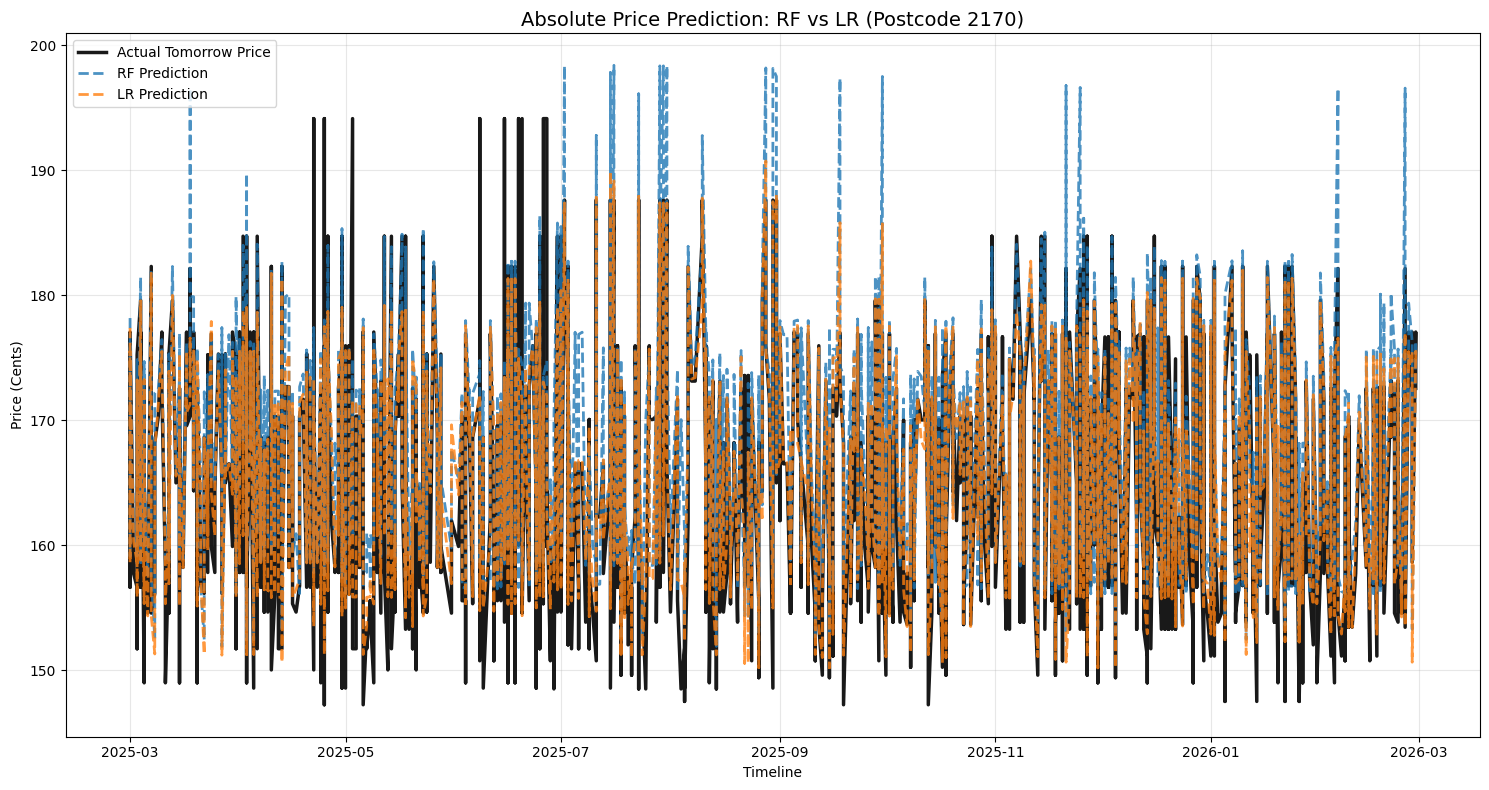

In [5]:
# 1. Reconstruct the test results with dates
# Assuming 'df_final' or your source CSV still exists with the 'date' column
df_source = pd.read_csv(COMPLETE_DATASET, parse_dates=['date'])

comparison_df = pd.DataFrame({
    'date': df_source.loc[X_test_chrono.index, 'date'],
    'postcode': X_test_chrono['postcode'],
    'actual': y_test_chrono,
    'rf_pred': baseline_rf_preds,
    'lr_pred': baseline_lr_preds
})

# 2. Pick a sample postcode
sample_postcode = comparison_df['postcode'].mode()[0]
plot_data = comparison_df[comparison_df['postcode'] == sample_postcode].sort_values('date')

# 3. Create the Comparison Plot
plt.figure(figsize=(15, 8))

# Actual price
plt.plot(plot_data['date'], plot_data['actual'], 
         label='Actual Tomorrow Price', color='black', lw=2.5, linestyle='-', alpha=0.9)

# Random Forest
plt.plot(plot_data['date'], plot_data['rf_pred'], 
         label='RF Prediction', color='#1f77b4', linestyle='--', alpha=0.8, lw=2)

# Linear Regression
plt.plot(plot_data['date'], plot_data['lr_pred'], 
         label='LR Prediction', color='#ff7f0e', linestyle='--', alpha=0.8, lw=2)

# REMOVED: plt.axhline(0) - No longer needed for absolute prices

plt.title(f'Absolute Price Prediction: RF vs LR (Postcode {sample_postcode})', fontsize=14)
plt.ylabel('Price (Cents)') # Updated label
plt.xlabel('Timeline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

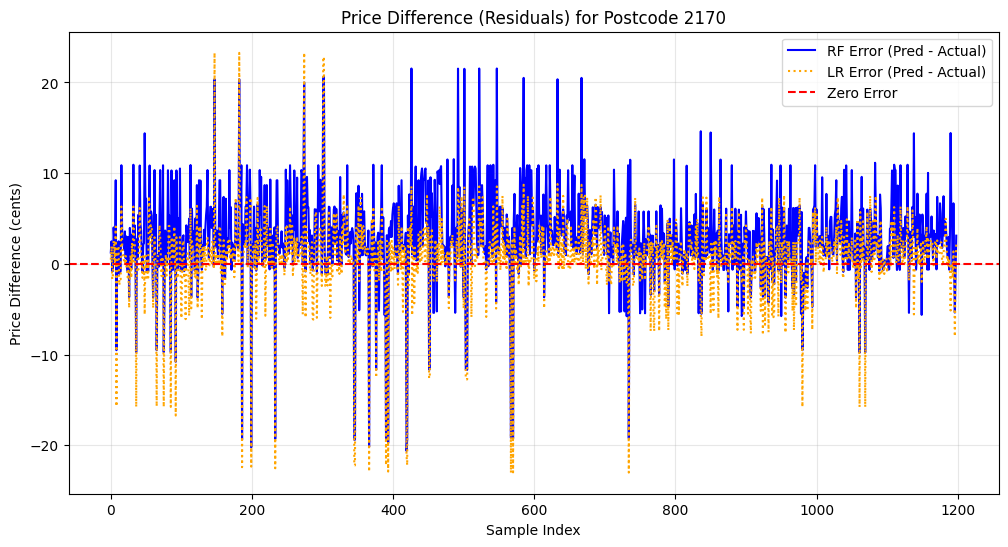

In [6]:
# Calculate the differences (Residuals)
plot_data['rf_diff'] = plot_data['rf_pred'] - plot_data['actual']
plot_data['lr_diff'] = plot_data['lr_pred'] - plot_data['actual']

plt.figure(figsize=(12, 6))

# Plotting the difference from zero
plt.plot(plot_data['rf_diff'].values, label='RF Error (Pred - Actual)', color='blue', linestyle="-")
plt.plot(plot_data['lr_diff'].values, label='LR Error (Pred - Actual)', color='orange', linestyle=":")

# Add a zero line to represent perfect prediction
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.title(f'Price Difference (Residuals) for Postcode {sample_postcode}')
plt.xlabel('Sample Index')
plt.ylabel('Price Difference (cents)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
